In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import (
    euclidean_distances,
    manhattan_distances,
    cosine_distances
)

df = pd.read_csv("diabetes.csv")
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Shape: (769, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [40]:
invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Missing values:")
print(df.isnull().sum())

print("\nInvalid zero values:")
for col in invalid_cols:
    print(col, ":", (df[col] == 0).sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Invalid zero values:
Glucose : 5
BloodPressure : 35
SkinThickness : 228
Insulin : 374
BMI : 11


In [41]:
df_clean = df.copy()

df_clean[invalid_cols] = df_clean[invalid_cols].replace(0, np.nan)

imputer = SimpleImputer(strategy="median")
df_clean[invalid_cols] = imputer.fit_transform(df_clean[invalid_cols])

print(df_clean.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [12]:
corr = df_clean.corr()

print(corr)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.127961       0.213385       0.100239   
Glucose                      0.127961  1.000000       0.223189       0.228043   
BloodPressure                0.213385  0.223189       1.000000       0.226839   
SkinThickness                0.100239  0.228043       0.226839       1.000000   
Insulin                      0.085256  0.579891       0.096353       0.184888   
BMI                          0.020861  0.232748       0.289427       0.648214   
DiabetesPedigreeFunction    -0.032500  0.137168      -0.003142       0.115016   
Age                          0.539932  0.266645       0.330250       0.166816   
Outcome                      0.219418  0.494123       0.171050       0.259491   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.085256  0.020861                 -0.032500   
Glucose                   0.579891  0.232

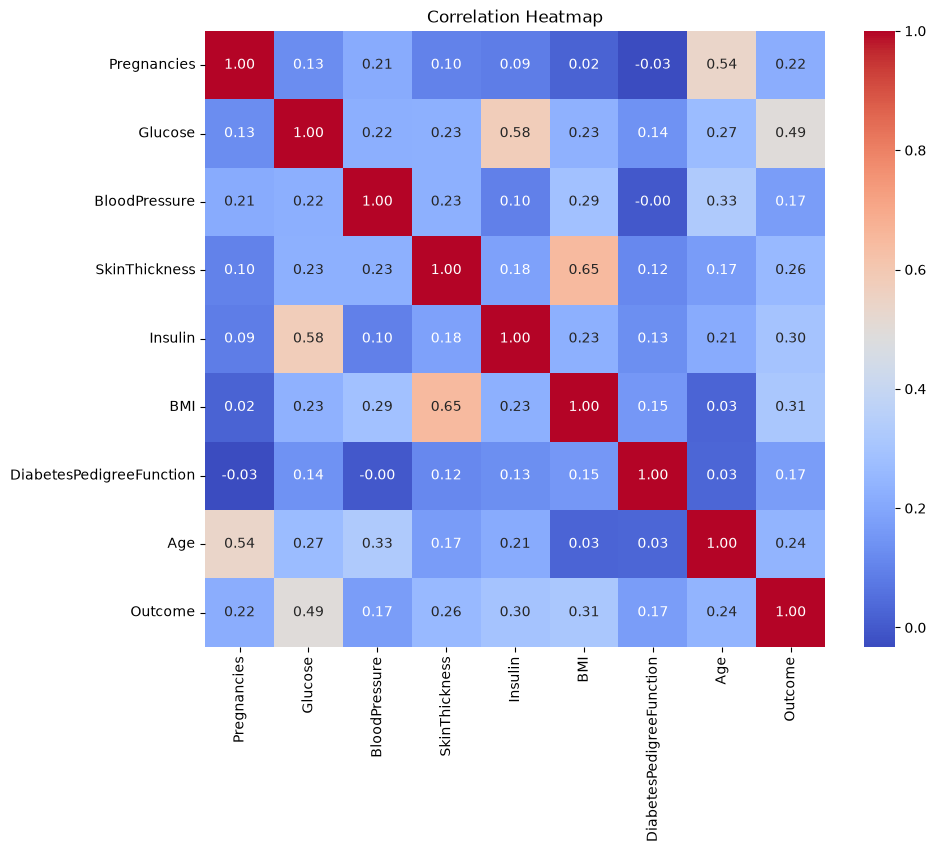

In [13]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [19]:
corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
stack=corr_pairs.stack().sort_values(ascending=False)
print(stack)

SkinThickness             BMI                         0.648214
Glucose                   Insulin                     0.579891
Pregnancies               Age                         0.539932
Glucose                   Outcome                     0.494123
BloodPressure             Age                         0.330250
BMI                       Outcome                     0.314229
Insulin                   Outcome                     0.297351
BloodPressure             BMI                         0.289427
Glucose                   Age                         0.266645
SkinThickness             Outcome                     0.259491
Age                       Outcome                     0.240816
Glucose                   BMI                         0.232748
                          SkinThickness               0.228043
BloodPressure             SkinThickness               0.226839
Insulin                   BMI                         0.225981
Glucose                   BloodPressure               0

In [20]:
print("Strongest Positive Corelation:")
print(stack.head(1))

print("\nStrongest Negative Corelation:")
print(stack.tail(1))

Strongest Positive Corelation:
SkinThickness  BMI    0.648214
dtype: float64

Strongest Negative Corelation:
Pregnancies  DiabetesPedigreeFunction   -0.0325
dtype: float64


In [28]:
features = df.drop(columns="Outcome").copy()
# Replace invalid zeros with NaN
features[invalid_cols] = features[invalid_cols].replace(0, np.nan)

# Median imputation
imputer = SimpleImputer(strategy="median")
features = pd.DataFrame(
    imputer.fit_transform(features),
    columns=features.columns
)

# Convert explicitly to float NumPy array
features = features.astype(float).to_numpy()

# Select two observations
x = features[0].reshape(1, -1)
y = features[1].reshape(1, -1)

print("Observation 1:", x)
print("Observation 2:", y)

Observation 1: [[  6.    148.     72.     35.    125.     33.6     0.627  50.   ]]
Observation 2: [[  1.     85.     66.     29.    125.     26.6     0.351  31.   ]]


In [35]:
euclidean = euclidean_distances(x, y)[0][0]
manhattan = manhattan_distances(x, y)[0][0]
cosine = cosine_distances(x, y)[0][0]

print("Euclidean Distance:", euclidean)
print("Manhattan Distance:", manhattan)
print("Cosine Distance:", cosine)

Euclidean Distance: 66.90348403483928
Manhattan Distance: 106.276
Cosine Distance: 0.03162267264593488


x shape: (1, 8)
y shape: (1, 8)
x dtype: float64
y dtype: float64
NaN: False False
Infinite: False False

Euclidean Distance: 66.90348403483928
Manhattan Distance: 106.276
Cosine Distance: 0.03162267264593488
